In [1]:
import warnings
warnings.filterwarnings('ignore')

#the basics
import pandas as pd, numpy as np
import math, json, gc, random, os, sys
from matplotlib import pyplot as plt
from tqdm import tqdm

#tensorflow deep learning basics
import tensorflow as tf
import tensorflow_addons as tfa
import tensorflow.keras.backend as K
import tensorflow.keras.layers as L

#for model evaluation
from sklearn.model_selection import train_test_split, KFold


2026-01-07 06:37:52.458675: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1767767872.471832      11 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1767767872.475962      11 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-07 06:37:52.492181: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

ModuleNotFoundError: No module named 'tensorflow_addons'

In [2]:
#get comp data
train = pd.read_json('/kaggle/input/stanford-covid-vaccine/train.json', lines=True)
test = pd.read_json('/kaggle/input/stanford-covid-vaccine/test.json', lines=True)
sample_sub = pd.read_csv('/kaggle/input/stanford-covid-vaccine/sample_submission.csv')


In [3]:
#sneak peak
print(train.shape)
if ~ train.isnull().values.any(): print('No missing values')
train.head()


(2160, 19)
No missing values


,index,id,sequence,structure,predicted_loop_type,signal_to_noise,SN_filter,seq_length,seq_scored,reactivity_error,deg_error_Mg_pH10,deg_error_pH10,deg_error_Mg_50C,deg_error_50C,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C
0,0,id_001f94081,GGAAAAGCUCUAAUAACAGGAGACUAGGACUACGUAUUUCUAGGUA...,.....((((((.......)))).)).((.....((..((((((......,EEEEESSSSSSHHHHHHHSSSSBSSXSSIIIIISSIISSSSSSHHH...,6.894,1,107,68,"[0.1359, 0.20700000000000002, 0.1633, 0.1452, ...","[0.26130000000000003, 0.38420000000000004, 0.1...","[0.2631, 0.28600000000000003, 0.0964, 0.1574, ...","[0.1501, 0.275, 0.0947, 0.18660000000000002, 0...","[0.2167, 0.34750000000000003, 0.188, 0.2124, 0...","[0.3297, 1.5693000000000001, 1.1227, 0.8686, 0...","[0.7556, 2.983, 0.2526, 1.3789, 0.637600000000...","[2.3375, 3.5060000000000002, 0.3008, 1.0108, 0...","[0.35810000000000003, 2.9683, 0.2589, 1.4552, ...","[0.6382, 3.4773, 0.9988, 1.3228, 0.78770000000..."
1,1,id_0049f53ba,GGAAAAAGCGCGCGCGGUUAGCGCGCGCUUUUGCGCGCGCUGUACC...,.....(((((((((((((((((((((((....)))))))))).)))...,EEEEESSSSSSSSSSSSSSSSSSSSSSSHHHHSSSSSSSSSSBSSS...,0.193,0,107,68,"[2.8272, 2.8272, 2.8272, 4.7343, 2.5676, 2.567...","[73705.3985, 73705.3985, 73705.3985, 73705.398...","[10.1986, 9.2418, 5.0933, 5.0933, 5.0933, 5.09...","[16.6174, 13.868, 8.1968, 8.1968, 8.1968, 8.19...","[15.4857, 7.9596, 13.3957, 5.8777, 5.8777, 5.8...","[0.0, 0.0, 0.0, 2.2965, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.947, 4.4523, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[4.8511, 4.0426, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[7.6692, 0.0, 10.9561, 0.0, 0.0, 0.0, 0.0, 0.0..."
2,2,id_006f36f57,GGAAAGUGCUCAGAUAAGCUAAGCUCGAAUAGCAAUCGAAUAGAAU...,.....((((.((.....((((.(((.....)))..((((......)...,EEEEESSSSISSIIIIISSSSMSSSHHHHHSSSMMSSSSHHHHHHS...,8.800,1,107,68,"[0.0931, 0.13290000000000002, 0.11280000000000...","[0.1365, 0.2237, 0.1812, 0.1333, 0.1148, 0.160...","[0.17020000000000002, 0.178, 0.111, 0.091, 0.0...","[0.1033, 0.1464, 0.1126, 0.09620000000000001, ...","[0.14980000000000002, 0.1761, 0.1517, 0.116700...","[0.44820000000000004, 1.4822, 1.1819, 0.743400...","[0.2504, 1.4021, 0.9804, 0.49670000000000003, ...","[2.243, 2.9361, 1.0553, 0.721, 0.6396000000000...","[0.5163, 1.6823000000000001, 1.0426, 0.7902, 0...","[0.9501000000000001, 1.7974999999999999, 1.499..."
3,3,id_0082d463b,GGAAAAGCGCGCGCGCGCGCGCGAAAAAGCGCGCGCGCGCGCGCGC...,......((((((((((((((((......))))))))))))))))((...,EEEEEESSSSSSSSSSSSSSSSHHHHHHSSSSSSSSSSSSSSSSSS...,0.104,0,107,68,"[3.5229, 6.0748, 3.0374, 3.0374, 3.0374, 3.037...","[73705.3985, 73705.3985, 73705.3985, 73705.398...","[11.8007, 12.7566, 5.7733, 5.7733, 5.7733, 5.7...","[121286.7181, 121286.7182, 121286.7181, 121286...","[15.3995, 8.1124, 7.7824, 7.7824, 7.7824, 7.78...","[0.0, 2.2399, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0....","[0.0, -0.5083, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[3.4248, 6.8128, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[0.0, -0.8365, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0...","[7.6692, -1.3223, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0..."
4,4,id_0087940f4,GGAAAAUAUAUAAUAUAUUAUAUAAAUAUAUUAUAGAAGUAUAAUA...,.....(((((((.((((((((((((.(((((((((....)))))))...,EEEEESSSSSSSBSSSSSSSSSSSSBSSSSSSSSSHHHHSSSSSSS...,0.423,0,107,68,"[1.665, 2.1728, 2.0041, 1.2405, 0.620200000000...","[4.2139, 3.9637000000000002, 3.2467, 2.4716, 1...","[3.0942, 3.015, 2.1212, 2.0552, 0.881500000000...","[2.6717, 2.4818, 1.9919, 2.5484999999999998, 1...","[1.3285, 3.6173, 1.3057, 1.3021, 1.1507, 1.150...","[0.8267, 2.6577, 2.8481, 0.40090000000000003, ...","[2.1058, 3.138, 2.5437000000000003, 1.0932, 0....","[4.7366, 4.6243, 1.2068, 1.1538, 0.0, 0.0, 0.7...","[2.2052, 1.7947000000000002, 0.7457, 3.1233, 0...","[0.0, 5.1198, -0.3551, -0.3518, 0.0, 0.0, 0.0,..."


In [4]:
#sneak peak
print(test.shape)
if ~ test.isnull().values.any(): print('No missing values')
test.head()


(240, 7)
No missing values


,index,id,sequence,structure,predicted_loop_type,seq_length,seq_scored
0,0,id_00b436dec,GGAAAUCAUCGAGGACGGGUCCGUUCAGCACGCGAAAGCGUCGUGA...,.....(((((((((((..(((((((((..((((....))))..)))...,EEEEESSSSSSSSSSSIISSSSSSSSSIISSSSHHHHSSSSIISSS...,107,68
1,1,id_010ab0472,GGAAAGCAUGGGACCACGAUUCACAUCGGUCUGCACGUAGGACAUU...,.....(((...((((..(((....))))))))))(((((((((......,EEEEESSSBBBSSSSBBSSSHHHHSSSSSSSSSSSSSSSSSSSIII...,107,68
2,2,id_01ccf95c0,GGAAAAGCGAACGACGAAACGCGGGCGCGAUGGACAGGAGGCUGAC...,......(((..((.((...))))..)))((((..(((...((((.....,EEEEEESSSIISSBSSHHHSSSSIISSSSSSSIISSSIIISSSSHH...,107,68
3,3,id_023f91e97,GGAAAUUAUAAUGAUCAUGAGGUACUAUCAUCAUGACUGGAGACAG...,..........(((.((.((..((.((.((.((.((.(((....)))...,EEEEEEEEEESSSBSSBSSIISSBSSBSSBSSBSSBSSSHHHHSSS...,107,68
4,4,id_0295caf90,GGAAACAGGGCAGGUCGAGUGAGGGAUCGAGGCGGGCGCGGUUCGG...,.........(((.(((..(((....((((((.((....)).)))))...,EEEEEEEEESSSISSSIISSSIIIISSSSSSISSHHHHSSISSSSS...,107,68


In [5]:
#sneak peak
print(sample_sub.shape)
if ~ sample_sub.isnull().values.any(): print('No missing values')
sample_sub.head()


(25680, 6)
No missing values


,id_seqpos,reactivity,deg_Mg_pH10,deg_pH10,deg_Mg_50C,deg_50C
0,id_00b436dec_0,0.0,0.0,0.0,0.0,0.0
1,id_00b436dec_1,0.0,0.0,0.0,0.0,0.0
2,id_00b436dec_2,0.0,0.0,0.0,0.0,0.0
3,id_00b436dec_3,0.0,0.0,0.0,0.0,0.0
4,id_00b436dec_4,0.0,0.0,0.0,0.0,0.0


In [6]:
#target columns
target_cols = ['reactivity', 'deg_Mg_pH10', 'deg_pH10', 'deg_Mg_50C', 'deg_50C']


In [7]:
token2int = {x:i for i, x in enumerate('().ACGUBEHIMSX')}


In [8]:
def preprocess_inputs(df, cols=['sequence', 'structure', 'predicted_loop_type']):
    return np.transpose(
        np.array(
            df[cols]
            .applymap(lambda seq: [token2int[x] for x in seq])
            .values
            .tolist()
        ),
        (0, 2, 1)
    )


In [9]:
train_inputs = preprocess_inputs(train[train.signal_to_noise > 1])
train_labels = np.array(train[train.signal_to_noise > 1][target_cols].values.tolist()).transpose((0, 2, 1))


In [10]:
def gru_layer(hidden_dim, dropout):
    return tf.keras.layers.Bidirectional(
                                tf.keras.layers.GRU(hidden_dim,
                                dropout=dropout,
                                return_sequences=True,
                                kernel_initializer = 'orthogonal'))

def lstm_layer(hidden_dim, dropout):
    return tf.keras.layers.Bidirectional(
                                tf.keras.layers.LSTM(hidden_dim,
                                dropout=dropout,
                                return_sequences=True,
                                kernel_initializer = 'orthogonal'))

def build_model(gru=False,seq_len=107, pred_len=68, dropout=0.5,
                embed_dim=75, hidden_dim=128):
    
    inputs = tf.keras.layers.Input(shape=(seq_len, 3))

    embed = tf.keras.layers.Embedding(input_dim=len(token2int), output_dim=embed_dim)(inputs)
    reshaped = tf.reshape(
        embed, shape=(-1, embed.shape[1],  embed.shape[2] * embed.shape[3]))
    
    reshaped = tf.keras.layers.SpatialDropout1D(.2)(reshaped)
    
    if gru:
        hidden = gru_layer(hidden_dim, dropout)(reshaped)
        hidden = gru_layer(hidden_dim, dropout)(hidden)
        hidden = gru_layer(hidden_dim, dropout)(hidden)
        
    else:
        hidden = lstm_layer(hidden_dim, dropout)(reshaped)
        hidden = lstm_layer(hidden_dim, dropout)(hidden)
        hidden = lstm_layer(hidden_dim, dropout)(hidden)
    
    #only making predictions on the first part of each sequence
    truncated = hidden[:, :pred_len]
    
    out = tf.keras.layers.Dense(5, activation='linear')(truncated)

    model = tf.keras.Model(inputs=inputs, outputs=out)

    #some optimizers
    adam = tf.optimizers.Adam()
    radam = tfa.optimizers.RectifiedAdam()
    lookahead = tfa.optimizers.Lookahead(adam, sync_period=6)
    ranger = tfa.optimizers.Lookahead(radam, sync_period=6)
    
    model.compile(optimizer = adam, loss='mse')
    
    return model


In [11]:
train_inputs, val_inputs, train_labels, val_labels = train_test_split(train_inputs, train_labels,
                                                                     test_size=.1, random_state=34)


NameError: name 'train_test_split' is not defined

In [12]:
if tf.config.list_physical_devices('GPU') is not None:
    print('Training on GPU')


Training on GPU


In [13]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau()


In [14]:
gru = build_model(gru=True)
sv_gru = tf.keras.callbacks.ModelCheckpoint('model_gru.h5')

history_gru = gru.fit(
    train_inputs, train_labels, 
    validation_data=(val_inputs,val_labels),
    batch_size=64,
    epochs=70,
    callbacks=[lr_callback,sv_gru],
    verbose = 2
)

print(f"Min training loss={min(history_gru.history['loss'])}, min validation loss={min(history_gru.history['val_loss'])}")


2026-01-07 06:37:59.935553: W tensorflow/core/common_runtime/gpu/gpu_bfc_allocator.cc:47] Overriding orig_value setting because the TF_FORCE_GPU_ALLOW_GROWTH environment variable is set. Original config value was 0.
I0000 00:00:1767767879.936019      11 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 46866 MB memory:  -> device: 0, name: NVIDIA RTX A6000, pci bus id: 0000:85:00.0, compute capability: 8.6


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [15]:
lstm = build_model(gru=False)
sv_lstm = tf.keras.callbacks.ModelCheckpoint('model_lstm.h5')

history_lstm = lstm.fit(
    train_inputs, train_labels, 
    validation_data=(val_inputs,val_labels),
    batch_size=64,
    epochs=75,
    callbacks=[lr_callback,sv_lstm],
    verbose = 2
)

print(f"Min training loss={min(history_lstm.history['loss'])}, min validation loss={min(history_lstm.history['val_loss'])}")


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


NameError: name 'history_gru' is not defined

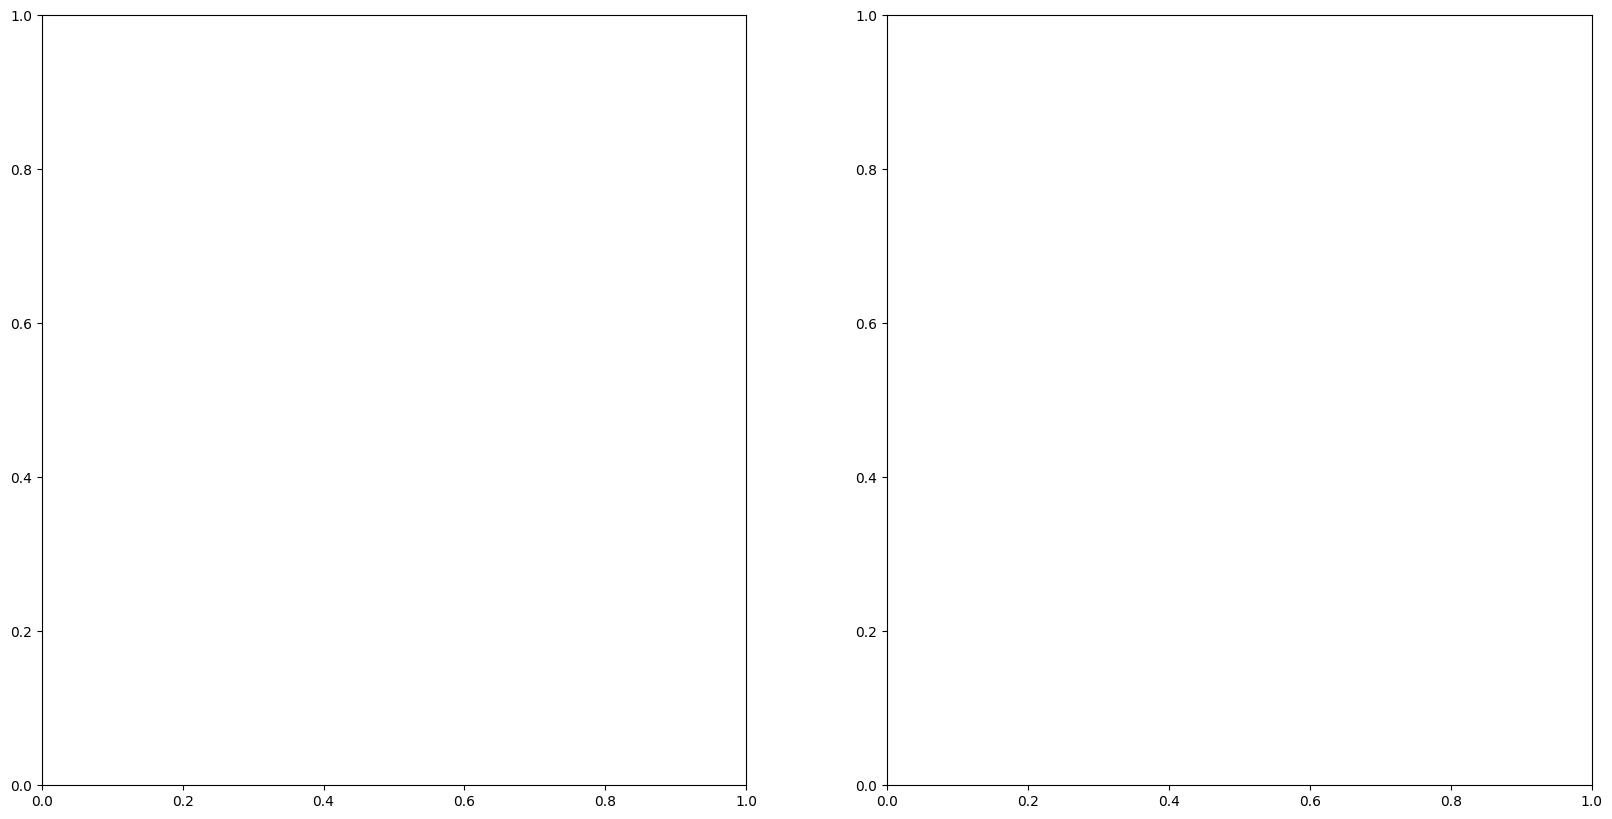

In [16]:
fig, ax = plt.subplots(1, 2, figsize = (20, 10))

ax[0].plot(history_gru.history['loss'])
ax[0].plot(history_gru.history['val_loss'])

ax[1].plot(history_lstm.history['loss'])
ax[1].plot(history_lstm.history['val_loss'])

ax[0].set_title('GRU')
ax[1].set_title('LSTM')

ax[0].legend(['train', 'validation'], loc = 'upper right')
ax[1].legend(['train', 'validation'], loc = 'upper right')

ax[0].set_ylabel('Loss')
ax[0].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_xlabel('Epoch');


In [17]:
public_df = test.query("seq_length == 107").copy()
private_df = test.query("seq_length == 130").copy()

public_inputs = preprocess_inputs(public_df)
private_inputs = preprocess_inputs(private_df)


ValueError: axes don't match array

In [18]:
#build all models
gru_short = build_model(gru=True, seq_len=107, pred_len=107)
gru_long = build_model(gru=True, seq_len=130, pred_len=130)
lstm_short = build_model(gru=False, seq_len=107, pred_len=107)
lstm_long = build_model(gru=False, seq_len=130, pred_len=130)

#load pre-trained model weights
gru_short.load_weights('model_gru.h5')
gru_long.load_weights('model_gru.h5')
lstm_short.load_weights('model_lstm.h5')
lstm_long.load_weights('model_lstm.h5')

#and predict
gru_public_preds = gru_short.predict(public_inputs)
gru_private_preds = gru_long.predict(private_inputs)
lstm_public_preds = lstm_short.predict(public_inputs)
lstm_private_preds = lstm_long.predict(private_inputs)


ValueError: A KerasTensor cannot be used as input to a TensorFlow function. A KerasTensor is a symbolic placeholder for a shape and dtype, used when constructing Keras Functional models or Keras Functions. You can only use it as input to a Keras layer or a Keras operation (from the namespaces `keras.layers` and `keras.operations`). You are likely doing something like:

```
x = Input(...)
...
tf_fn(x)  # Invalid.
```

What you should do instead is wrap `tf_fn` in a layer:

```
class MyLayer(Layer):
    def call(self, x):
        return tf_fn(x)

x = MyLayer()(x)
```


In [19]:
preds_gru = []

for df, preds in [(public_df, gru_public_preds), (private_df, gru_private_preds)]:
    for i, uid in enumerate(df.id):
        single_pred = preds[i]

        single_df = pd.DataFrame(single_pred, columns=target_cols)
        single_df['id_seqpos'] = [f'{uid}_{x}' for x in range(single_df.shape[0])]

        preds_gru.append(single_df)

preds_gru_df = pd.concat(preds_gru)
preds_gru_df.head()


NameError: name 'gru_public_preds' is not defined

In [20]:
preds_lstm = []

for df, preds in [(public_df, lstm_public_preds), (private_df, lstm_private_preds)]:
    for i, uid in enumerate(df.id):
        single_pred = preds[i]

        single_df = pd.DataFrame(single_pred, columns=target_cols)
        single_df['id_seqpos'] = [f'{uid}_{x}' for x in range(single_df.shape[0])]

        preds_lstm.append(single_df)

preds_lstm_df = pd.concat(preds_lstm)
preds_lstm_df.head()


NameError: name 'lstm_public_preds' is not defined

In [21]:
blend_preds_df = pd.DataFrame()
blend_preds_df['id_seqpos'] = preds_gru_df['id_seqpos']
blend_preds_df['reactivity'] = .5*preds_gru_df['reactivity'] + .5*preds_lstm_df['reactivity']
blend_preds_df['deg_Mg_pH10'] = .5*preds_gru_df['deg_Mg_pH10'] + .5*preds_lstm_df['deg_Mg_pH10']
blend_preds_df['deg_pH10'] = .5*preds_gru_df['deg_pH10'] + .5*preds_lstm_df['deg_pH10']
blend_preds_df['deg_Mg_50C'] = .5*preds_gru_df['deg_Mg_50C'] + .5*preds_lstm_df['deg_Mg_50C']
blend_preds_df['deg_50C'] = .5*preds_gru_df['deg_50C'] + .5*preds_lstm_df['deg_50C']


NameError: name 'preds_gru_df' is not defined

In [22]:
submission = sample_sub[['id_seqpos']].merge(blend_preds_df, on=['id_seqpos'])

#sanity check
submission.head()


KeyError: 'id_seqpos'

In [23]:
submission.to_csv('submission.csv', index=False)
print('Submission saved')


NameError: name 'submission' is not defined